# Exploración ENIGH 2016–2024: ¿México reduce la pobreza de forma equitativa?

**Pregunta guía:** ¿México está reduciendo la pobreza de forma equitativa, o hay regiones que se están quedando atrás?

**Fuente:** Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH), INEGI.  
**Años disponibles:** 2016, 2018, 2020, 2022, 2024  
**Tabla central:** `concentradohogar` — ingreso y gasto por hogar, con clave geográfica.

---

### Variables clave que usaremos
| Variable | Descripción |
|---|---|
| `ubica_geo` | Clave municipio (primeros 2 dígitos = estado) |
| `factor` | Factor de expansión (peso muestral) |
| `ing_cor` | Ingreso corriente trimestral del hogar |
| `gasto_mon` | Gasto monetario trimestral del hogar |
| `tot_integ` | Número de integrantes del hogar |
| `tam_loc` | Tamaño de localidad (urbano/rural) |
| `est_socio` | Estrato socioeconómico |

**Proxy de pobreza:** ingreso corriente per cápita mensual (`ing_cor / tot_integ / 3`)  
Este valor se puede comparar contra las líneas de bienestar del CONEVAL.

## 0. Setup e imports

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import os

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110

# Path relativo — Jupyter establece CWD al directorio del notebook
BASE = Path(".")
IMG_DIR = BASE / "imagenes"
IMG_DIR.mkdir(exist_ok=True)

print("Base:", Path(".").resolve())
print("Directorios encontrados:", [d.name for d in BASE.iterdir() if d.is_dir()])


Base: C:\Users\Jhoshua\OneDrive\Documentos\Ciencia de Datos\Hackathones\hackods\Posibles Datos Melisa\HackODS
Directorios encontrados: ['conjunto_de_datos_enigh2024_ns_csv', 'conjunto_de_datos_enigh_2016_ns_csv', 'conjunto_de_datos_enigh_2018_ns_csv', 'conjunto_de_datos_enigh_ns_2020_csv', 'conjunto_de_datos_enigh_ns_2022_csv', 'imagenes']


## 1. Carga de datos: todos los años

In [54]:
# Rutas a concentradohogar por año
PATHS = {
    2016: BASE / "conjunto_de_datos_enigh_2016_ns_csv"
               / "conjunto_de_datos_concentradohogar_enigh_2016_ns"
               / "conjunto_de_datos"
               / "conjunto_de_datos_concentradohogar_enigh_2016_ns.csv",
    2018: BASE / "conjunto_de_datos_enigh_2018_ns_csv"
               / "conjunto_de_datos_concentradohogar_enigh_2018_ns"
               / "conjunto_de_datos"
               / "conjunto_de_datos_concentradohogar_enigh_2018_ns.csv",
    2020: BASE / "conjunto_de_datos_enigh_ns_2020_csv"
               / "conjunto_de_datos_concentradohogar_enigh_2020_ns"
               / "conjunto_de_datos"
               / "conjunto_de_datos_concentradohogar_enigh_2020_ns.csv",
    2022: BASE / "conjunto_de_datos_enigh_ns_2022_csv"
               / "conjunto_de_datos_concentradohogar_enigh2022_ns"
               / "conjunto_de_datos"
               / "conjunto_de_datos_concentradohogar_enigh2022_ns.csv",
    2024: BASE / "conjunto_de_datos_enigh2024_ns_csv"
               / "conjunto_de_datos_concentradohogar_enigh2024_ns"
               / "conjunto_de_datos"
               / "conjunto_de_datos_concentradohogar_enigh2024_ns.csv",
}

# Columnas de interés
COLS = ["folioviv", "foliohog", "ubica_geo", "tam_loc", "est_socio",
        "factor", "tot_integ", "ing_cor", "gasto_mon",
        "ingtrab", "transfer", "bene_gob", "remesas",
        "sexo_jefe", "edad_jefe", "educa_jefe"]

frames = []
for year, path in PATHS.items():
    print(f"{year}: ", end="")
    df = pd.read_csv(path, usecols=lambda c: c in COLS, encoding="utf-8-sig", low_memory=False)
    df["anio"] = year
    frames.append(df)
    print(f"{len(df):,} hogares  |  columnas: {list(df.columns)}")

raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal registros: {len(raw):,}")
raw.head(3)

2016: 70,311 hogares  |  columnas: ['folioviv', 'foliohog', 'ubica_geo', 'tam_loc', 'est_socio', 'factor', 'sexo_jefe', 'edad_jefe', 'educa_jefe', 'tot_integ', 'ing_cor', 'ingtrab', 'transfer', 'remesas', 'bene_gob', 'gasto_mon', 'anio']
2018: 74,647 hogares  |  columnas: ['folioviv', 'foliohog', 'ubica_geo', 'tam_loc', 'est_socio', 'factor', 'sexo_jefe', 'edad_jefe', 'educa_jefe', 'tot_integ', 'ing_cor', 'ingtrab', 'transfer', 'remesas', 'bene_gob', 'gasto_mon', 'anio']
2020: 89,006 hogares  |  columnas: ['folioviv', 'foliohog', 'ubica_geo', 'tam_loc', 'est_socio', 'factor', 'sexo_jefe', 'edad_jefe', 'educa_jefe', 'tot_integ', 'ing_cor', 'ingtrab', 'transfer', 'remesas', 'bene_gob', 'gasto_mon', 'anio']
2022: 90,102 hogares  |  columnas: ['folioviv', 'foliohog', 'ubica_geo', 'tam_loc', 'est_socio', 'factor', 'sexo_jefe', 'edad_jefe', 'educa_jefe', 'tot_integ', 'ing_cor', 'ingtrab', 'transfer', 'remesas', 'bene_gob', 'gasto_mon', 'anio']
2024: 91,414 hogares  |  columnas: ['folioviv', 

,folioviv,foliohog,ubica_geo,tam_loc,est_socio,factor,sexo_jefe,edad_jefe,educa_jefe,tot_integ,ing_cor,ingtrab,transfer,remesas,bene_gob,gasto_mon,anio
0,100003801,1,10010000,1,4,248,1,33,10,2,100696.70,100696.70,0.00,0.0,0.0,46599.96,2016
1,100003802,1,10010000,1,4,248,1,29,10,2,146616.16,144157.15,2459.01,0.0,0.0,82427.75,2016
2,100003803,1,10010000,1,4,248,1,47,10,6,94622.95,82622.95,0.00,0.0,0.0,54792.51,2016


## 2. Limpieza y variables derivadas

In [55]:
df = raw.copy()

# --- Geografía ---
# ubica_geo tiene dos formatos según el año:
# 2018-2024: 4-5 dígitos EEMM/EEMMM → // 1000
# 2016:      8-9 dígitos EEMMMLLL  → // 10000000
df["cve_ent"] = df["ubica_geo"].map(lambda x: x // 10000000 if x >= 10000000 else x // 1000)

ESTADOS = {
    1:"Aguascalientes", 2:"Baja California", 3:"Baja California Sur",
    4:"Campeche", 5:"Coahuila", 6:"Colima", 7:"Chiapas", 8:"Chihuahua",
    9:"Ciudad de México", 10:"Durango", 11:"Guanajuato", 12:"Guerrero",
    13:"Hidalgo", 14:"Jalisco", 15:"Estado de México", 16:"Michoacán",
    17:"Morelos", 18:"Nayarit", 19:"Nuevo León", 20:"Oaxaca",
    21:"Puebla", 22:"Querétaro", 23:"Quintana Roo", 24:"San Luis Potosí",
    25:"Sinaloa", 26:"Sonora", 27:"Tabasco", 28:"Tamaulipas",
    29:"Tlaxcala", 30:"Veracruz", 31:"Yucatán", 32:"Zacatecas"
}
df["estado"] = df["cve_ent"].map(ESTADOS)

# Macroregiones (clasificación INEGI)
REGION = {
    1:"Norte", 2:"Norte", 3:"Norte", 5:"Norte", 8:"Norte",
    10:"Norte", 18:"Norte", 19:"Norte", 24:"Norte", 25:"Norte",
    26:"Norte", 28:"Norte", 32:"Norte",
    4:"Sur-Sureste", 7:"Sur-Sureste", 12:"Sur-Sureste", 20:"Sur-Sureste",
    23:"Sur-Sureste", 27:"Sur-Sureste", 30:"Sur-Sureste", 31:"Sur-Sureste",
    6:"Centro-Occidente", 11:"Centro-Occidente", 14:"Centro-Occidente",
    16:"Centro-Occidente", 17:"Centro-Occidente",
    9:"Centro", 13:"Centro", 15:"Centro", 21:"Centro",
    22:"Centro", 29:"Centro",
}
df["region"] = df["cve_ent"].map(REGION).fillna("Otro")

# --- Ingreso per cápita mensual (trimestral / 3) ---
df["ing_pc_mes"] = df["ing_cor"] / df["tot_integ"].clip(lower=1) / 3
df["gasto_pc_mes"] = df["gasto_mon"] / df["tot_integ"].clip(lower=1) / 3

# --- Urbano / Rural según tam_loc ---
# 1=100k+, 2=15k-99k, 3=2.5k-14.9k, 4=menos de 2.5k
df["zona"] = df["tam_loc"].map({1:"Urbano", 2:"Urbano", 3:"Rural", 4:"Rural"})

# --- Líneas de bienestar CONEVAL (referencia aproximada, pesos corrientes) ---
# Usamos una línea única orientativa para etiquetar; el análisis real requiere
# deflactar o usar líneas por año. Aquí marcamos pobreza extrema con línea rural 2024.
LINEAS_BIENESTAR = {
    # (anio, zona): línea per cápita mensual (pesos)
    2016: {"Urbano": 2542, "Rural": 1614},
    2018: {"Urbano": 2716, "Rural": 1726},
    2020: {"Urbano": 3148, "Rural": 2116},
    2022: {"Urbano": 4189, "Rural": 2802},
    2024: {"Urbano": 5000, "Rural": 3300},  # estimado orientativo
}

def clasifica_pobreza(row):
    lineas = LINEAS_BIENESTAR.get(row["anio"], {})
    lb = lineas.get(row["zona"], np.nan)
    if pd.isna(lb) or pd.isna(row["ing_pc_mes"]):
        return np.nan
    return 1 if row["ing_pc_mes"] < lb else 0

df["pobre_lb"] = df.apply(clasifica_pobreza, axis=1)

print(df[["anio","estado","region","zona","ing_pc_mes","gasto_pc_mes","pobre_lb"]].head())
print(f"\nShape: {df.shape}")
df.dtypes

   anio          estado region    zona    ing_pc_mes  gasto_pc_mes  pobre_lb
0  2016  Aguascalientes  Norte  Urbano  16782.783333   7766.660000         0
1  2016  Aguascalientes  Norte  Urbano  24436.026667  13737.958333         0
2  2016  Aguascalientes  Norte  Urbano   5256.830556   3044.028333         0
3  2016  Aguascalientes  Norte  Urbano   6475.405556   4716.930000         0
4  2016  Aguascalientes  Norte  Urbano   9549.178333   7931.548333         0

Shape: (415480, 24)


folioviv          int64
foliohog          int64
ubica_geo         int64
tam_loc           int64
est_socio         int64
factor            int64
sexo_jefe         int64
edad_jefe         int64
educa_jefe        int64
tot_integ         int64
ing_cor         float64
ingtrab         float64
transfer        float64
remesas         float64
bene_gob        float64
gasto_mon       float64
anio              int64
cve_ent           int64
estado           object
region           object
ing_pc_mes      float64
gasto_pc_mes    float64
zona             object
pobre_lb          int64
dtype: object

## 3. Calidad de datos: valores nulos, outliers, cobertura

In [56]:
# --- Nulos por columna clave ---
key_cols = ["ing_cor", "gasto_mon", "tot_integ", "factor", "ubica_geo", "zona"]
print("=== Nulos por columna clave ===")
print(df[key_cols].isnull().sum().to_string())

# --- Hogares por año ---
print("\n=== Hogares (muestra) por año ===")
print(df.groupby("anio").size().rename("hogares_muestra").to_string())

# --- Ingreso cero o negativo ---
print("\n=== Hogares con ing_cor <= 0 por año ===")
print(df[df["ing_cor"] <= 0].groupby("anio").size().to_string())

# --- Percentiles del ingreso per cápita por año ---
print("\n=== Percentiles ing_pc_mes por año ===")
df.groupby("anio")["ing_pc_mes"].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).unstack(level=1).round(0)

=== Nulos por columna clave ===
ing_cor      0
gasto_mon    0
tot_integ    0
factor       0
ubica_geo    0
zona         0

=== Hogares (muestra) por año ===
anio
2016    70311
2018    74647
2020    89006
2022    90102
2024    91414

=== Hogares con ing_cor <= 0 por año ===
anio
2016     6
2018     8
2020    13
2022     9
2024     6

=== Percentiles ing_pc_mes por año ===


,0.05,0.25,0.50,0.75,0.95
anio,,,,,
2016,874.0,1822.0,2992.0,5172.0,12906.0
2018,991.0,2104.0,3441.0,5862.0,14373.0
2020,1058.0,2254.0,3715.0,6311.0,15042.0
2022,1502.0,3093.0,5017.0,8381.0,19439.0
2024,1821.0,3802.0,6184.0,10260.0,23121.0


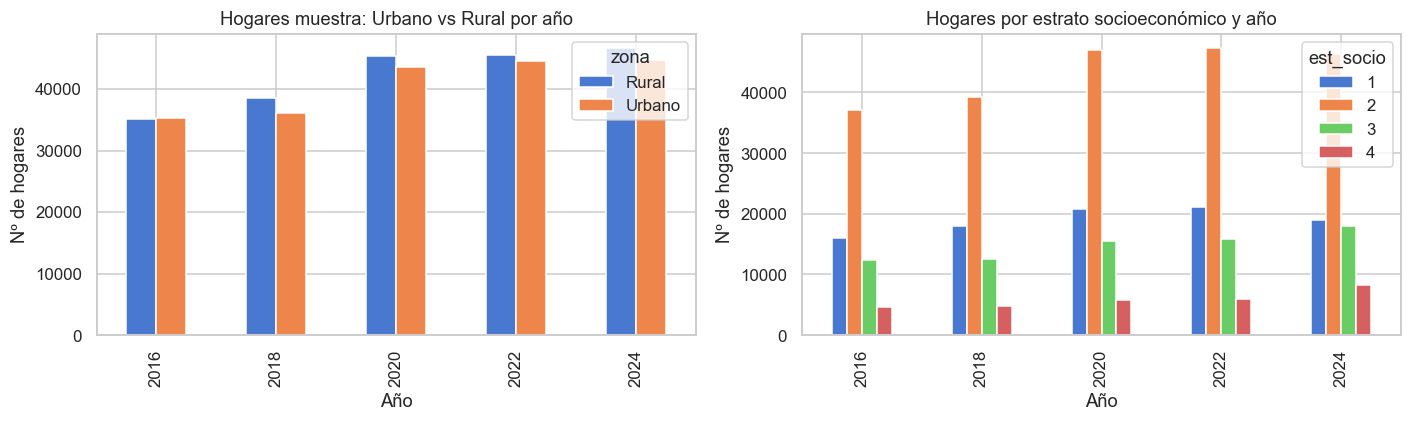

In [57]:
# Distribución de zonas y estratos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby(["anio","zona"]).size().unstack().plot(
    kind="bar", ax=axes[0], title="Hogares muestra: Urbano vs Rural por año"
)
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Nº de hogares")

df.groupby(["anio","est_socio"]).size().unstack().plot(
    kind="bar", ax=axes[1], title="Hogares por estrato socioeconómico y año"
)
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Nº de hogares")
plt.tight_layout()
plt.savefig(IMG_DIR / "mel_calidad_datos.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Tendencia nacional: ¿el ingreso medio mejora?

Usamos el **factor de expansión** para estimar el ingreso promedio ponderado a nivel nacional.

 anio  ing_pc_media  ing_pc_mediana  gasto_pc_media
 2016        5214.0          3171.0          3166.0
 2018        5700.0          3636.0          3633.0
 2020        5796.0          3839.0          3420.0
 2022        7638.0          5148.0          4752.0
 2024        9580.0          6609.0          5854.0


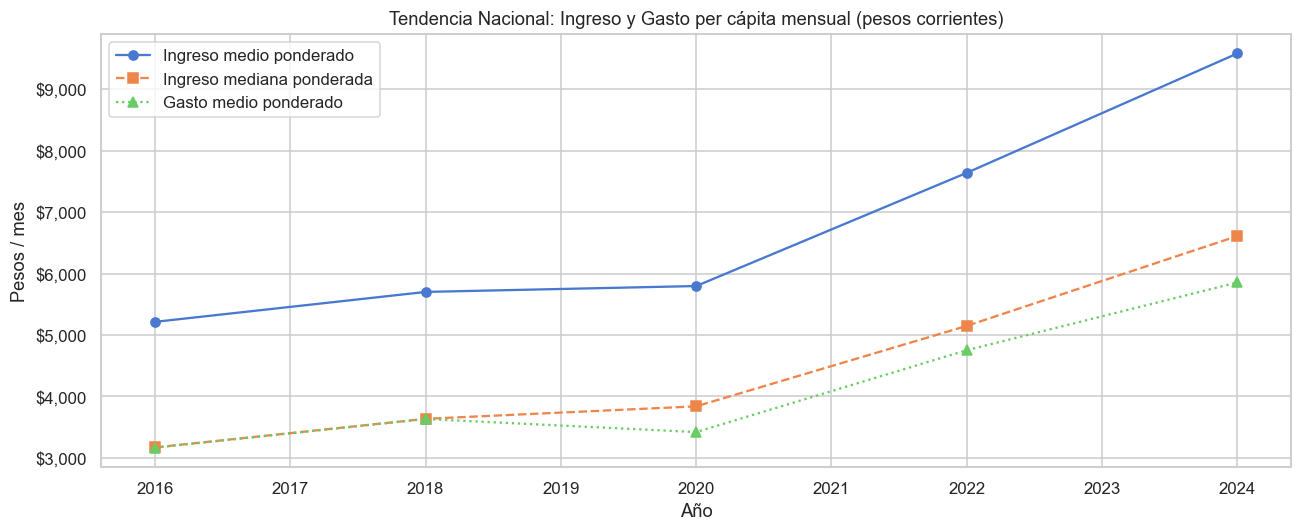


⚠️  Valores en pesos corrientes. La tendencia positiva incluye inflación.


In [58]:
def weighted_mean(values, weights):
    """Media ponderada ignorando NaN."""
    mask = values.notna() & weights.notna()
    return np.average(values[mask], weights=weights[mask])

def weighted_median(values, weights):
    """Mediana ponderada."""
    mask = values.notna() & weights.notna()
    v, w = values[mask].values, weights[mask].values
    idx = np.argsort(v)
    v, w = v[idx], w[idx]
    cumw = np.cumsum(w)
    cutoff = cumw[-1] / 2
    return v[np.searchsorted(cumw, cutoff)]

nacional = df.groupby("anio").apply(
    lambda g: pd.Series({
        "ing_pc_media":  weighted_mean(g["ing_pc_mes"], g["factor"]),
        "ing_pc_mediana": weighted_median(g["ing_pc_mes"], g["factor"]),
        "gasto_pc_media": weighted_mean(g["gasto_pc_mes"], g["factor"]),
    }),
    include_groups=False
).reset_index()

print(nacional.round(0).to_string(index=False))

fig, ax = plt.subplots()
ax.plot(nacional["anio"], nacional["ing_pc_media"], marker="o", label="Ingreso medio ponderado")
ax.plot(nacional["anio"], nacional["ing_pc_mediana"], marker="s", linestyle="--", label="Ingreso mediana ponderada")
ax.plot(nacional["anio"], nacional["gasto_pc_media"], marker="^", linestyle=":", label="Gasto medio ponderado")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Tendencia Nacional: Ingreso y Gasto per cápita mensual (pesos corrientes)")
ax.set_xlabel("Año")
ax.set_ylabel("Pesos / mes")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "mel_tendencia_nacional.png", dpi=150, bbox_inches="tight")
plt.show()

# ⚠️ NOTA: Los valores están en pesos corrientes (sin deflactar).
# Para comparación real entre años se necesita el deflactor del INEGI.
print("\n⚠️  Valores en pesos corrientes. La tendencia positiva incluye inflación.")

## 5. Análisis por región: ¿quién se queda atrás?

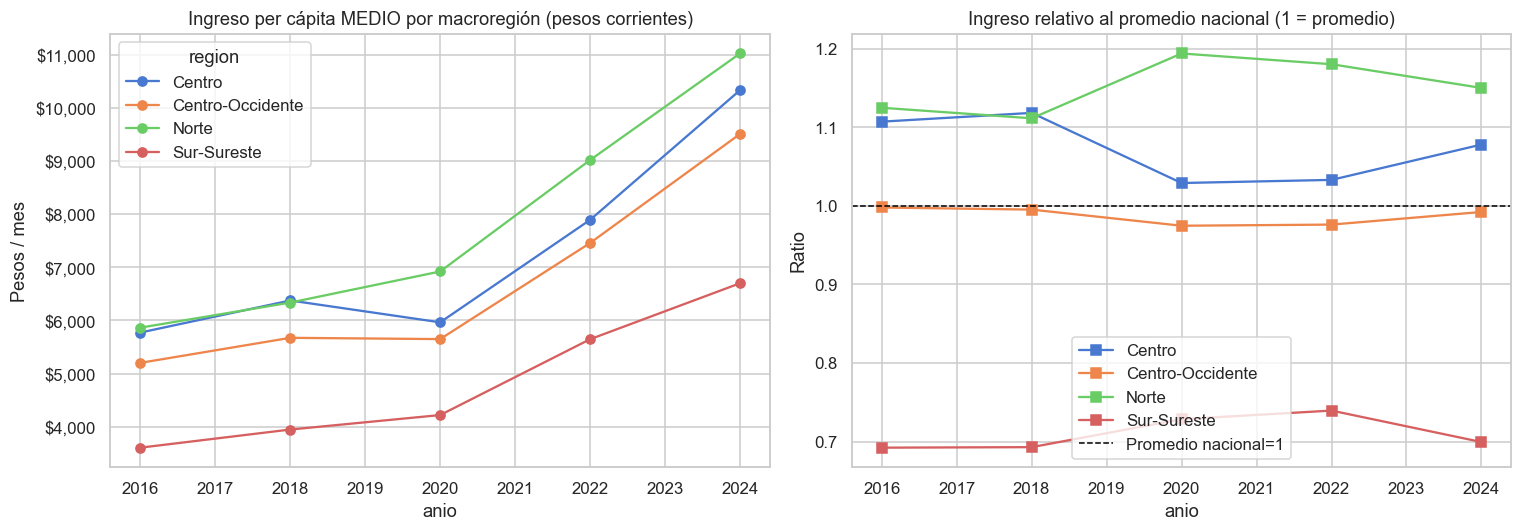


Ingreso medio por región (pesos corrientes):
region   Centro  Centro-Occidente    Norte  Sur-Sureste
anio                                                   
2016     5773.0            5203.0   5865.0       3609.0
2018     6376.0            5674.0   6336.0       3949.0
2020     5965.0            5650.0   6921.0       4222.0
2022     7891.0            7456.0   9016.0       5647.0
2024    10329.0            9506.0  11019.0       6700.0


In [59]:
por_region = df.groupby(["anio","region"]).apply(
    lambda g: pd.Series({
        "ing_pc_media": weighted_mean(g["ing_pc_mes"], g["factor"]),
        "ing_pc_mediana": weighted_median(g["ing_pc_mes"], g["factor"]),
    }),
    include_groups=False
).reset_index()

pivot_media = por_region.pivot(index="anio", columns="region", values="ing_pc_media")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_media.plot(ax=axes[0], marker="o")
axes[0].set_title("Ingreso per cápita MEDIO por macroregión (pesos corrientes)")
axes[0].set_ylabel("Pesos / mes")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Brecha relativa: cada región / promedio nacional
nac_media = nacional.set_index("anio")["ing_pc_media"]
brecha = pivot_media.div(nac_media, axis=0)
brecha.plot(ax=axes[1], marker="s")
axes[1].axhline(1, color="black", linewidth=1, linestyle="--", label="Promedio nacional=1")
axes[1].set_title("Ingreso relativo al promedio nacional (1 = promedio)")
axes[1].set_ylabel("Ratio")
axes[1].legend()

plt.tight_layout()
plt.savefig(IMG_DIR / "mel_ingreso_region.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nIngreso medio por región (pesos corrientes):")
print(pivot_media.round(0).to_string())

## 6. Análisis por estado: ranking y evolución

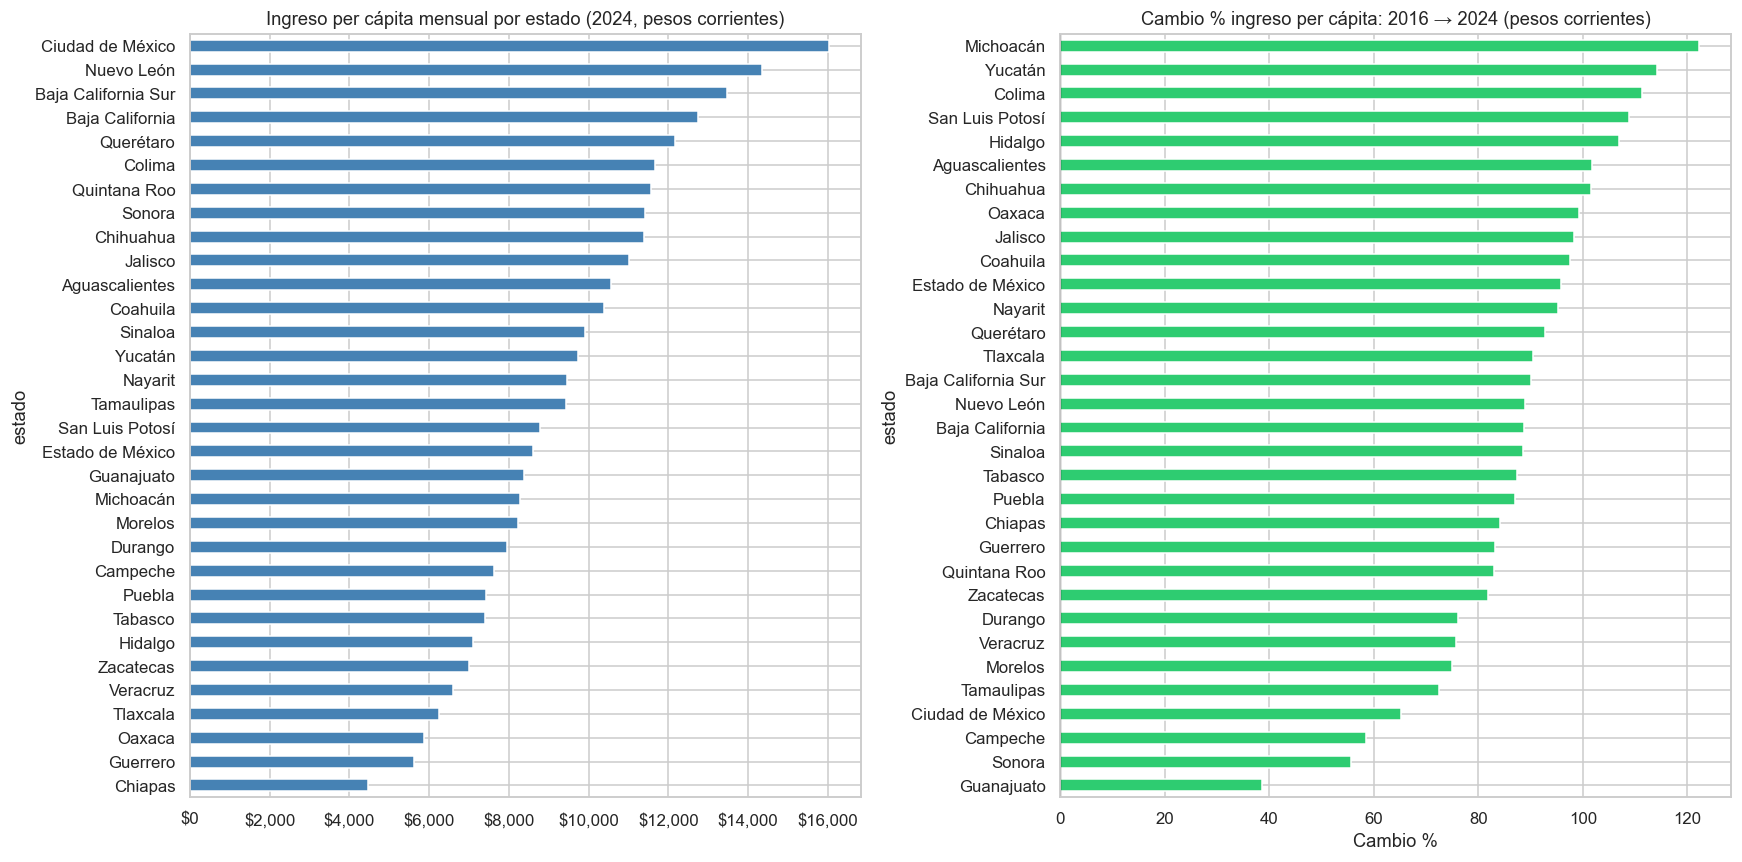


Estados con MAYOR crecimiento 2016-2024 (pesos corrientes):
                 ing_2016  ing_2024  cambio_pct
estado                                         
Michoacán          3727.4    8286.0       122.3
Yucatán            4542.4    9731.4       114.2
Colima             5513.7   11652.7       111.3
San Luis Potosí    4209.1    8792.0       108.9
Hidalgo            3425.9    7091.1       107.0

Estados con MENOR crecimiento 2016-2024 (pesos corrientes):
                  ing_2016  ing_2024  cambio_pct
estado                                          
Tamaulipas          5473.3    9438.6        72.4
Ciudad de México    9712.2   16038.0        65.1
Campeche            4809.8    7622.1        58.5
Sonora              7325.4   11407.5        55.7
Guanajuato          6038.2    8373.4        38.7


In [60]:
por_estado = df.groupby(["anio","estado"]).apply(
    lambda g: pd.Series({
        "ing_pc_media": weighted_mean(g["ing_pc_mes"], g["factor"]),
        "ing_pc_mediana": weighted_median(g["ing_pc_mes"], g["factor"]),
        "n_hogares": len(g),
    }),
    include_groups=False
).reset_index()

# Comparación 2016 vs 2024
comp = por_estado[por_estado["anio"].isin([2016, 2024])].pivot(
    index="estado", columns="anio", values="ing_pc_media"
).dropna()
comp.columns = ["ing_2016", "ing_2024"]
comp["cambio_pct"] = (comp["ing_2024"] / comp["ing_2016"] - 1) * 100
comp = comp.sort_values("cambio_pct", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Ranking por ingreso 2024
comp.sort_values("ing_2024")["ing_2024"].plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Ingreso per cápita mensual por estado (2024, pesos corrientes)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Cambio % 2016-2024
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in comp.sort_values("cambio_pct")["cambio_pct"]]
comp.sort_values("cambio_pct")["cambio_pct"].plot(
    kind="barh", ax=axes[1], color=colors
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Cambio % ingreso per cápita: 2016 → 2024 (pesos corrientes)")
axes[1].set_xlabel("Cambio %")

plt.tight_layout()
plt.savefig(IMG_DIR / "mel_ranking_estados.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nEstados con MAYOR crecimiento 2016-2024 (pesos corrientes):")
print(comp.head(5)[["ing_2016","ing_2024","cambio_pct"]].round(1).to_string())
print("\nEstados con MENOR crecimiento 2016-2024 (pesos corrientes):")
print(comp.tail(5)[["ing_2016","ing_2024","cambio_pct"]].round(1).to_string())

## 7. Brecha urbano-rural por región

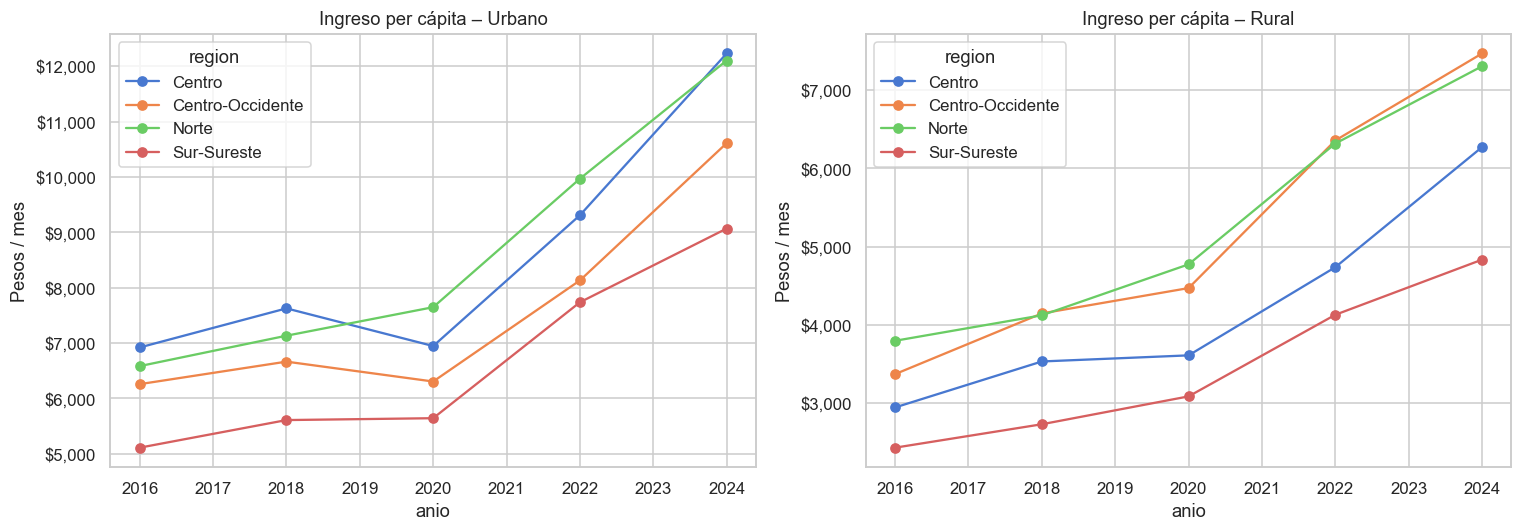

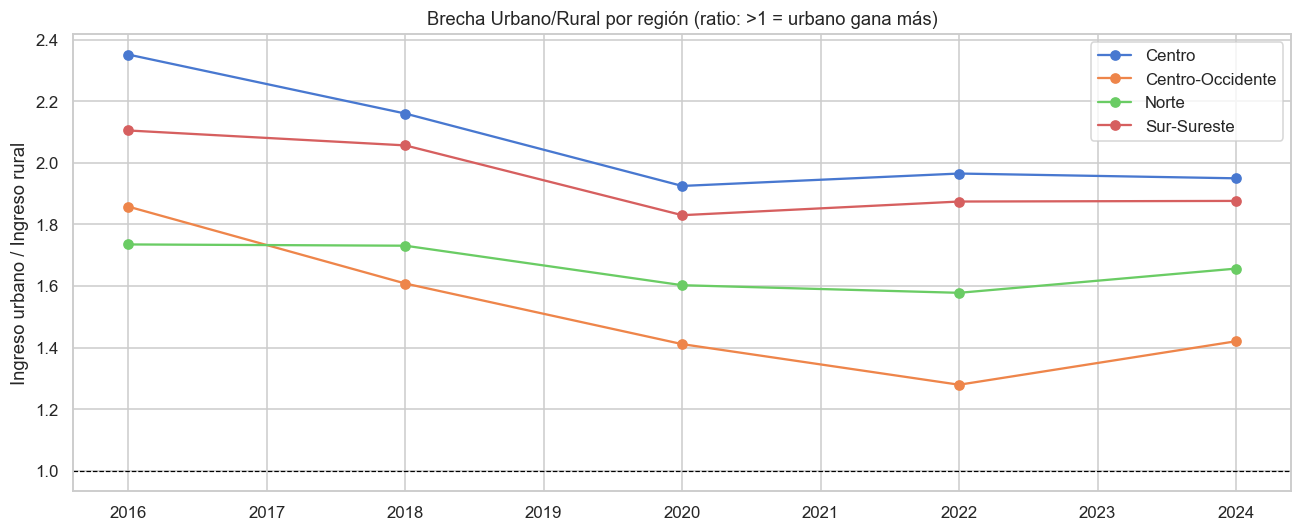

In [68]:
por_zona = df.groupby(["anio","region","zona"]).apply(
    lambda g: weighted_mean(g["ing_pc_mes"], g["factor"]),
    include_groups=False
).reset_index(name="ing_pc_media")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolución urbano vs rural por región
for zona, ax in zip(["Urbano", "Rural"], axes):
    sub = por_zona[por_zona["zona"] == zona]
    pivot = sub.pivot(index="anio", columns="region", values="ing_pc_media")
    pivot.plot(ax=ax, marker="o")
    ax.set_title(f"Ingreso per cápita – {zona}")
    ax.set_ylabel("Pesos / mes")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig(IMG_DIR / "mel_brecha_urbano_rural.png", dpi=150, bbox_inches="tight")
plt.savefig(IMG_DIR / "mel_ratio_urbano_rural.png", dpi=150, bbox_inches="tight")
plt.show()

# Ratio urbano/rural (brecha) por región y año
ratio = por_zona.pivot_table(
    index=["anio","region"], columns="zona", values="ing_pc_media"
).reset_index()
ratio["ratio_urb_rur"] = ratio["Urbano"] / ratio["Rural"]

fig, ax = plt.subplots()
for region in ratio["region"].unique():
    sub = ratio[ratio["region"] == region]
    ax.plot(sub["anio"], sub["ratio_urb_rur"], marker="o", label=region)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Brecha Urbano/Rural por región (ratio: >1 = urbano gana más)")
ax.set_ylabel("Ingreso urbano / Ingreso rural")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Desigualdad interna: coeficiente de Gini por región y año

El Gini mide qué tan concentrado está el ingreso (0 = perfecta igualdad, 1 = todo para uno).

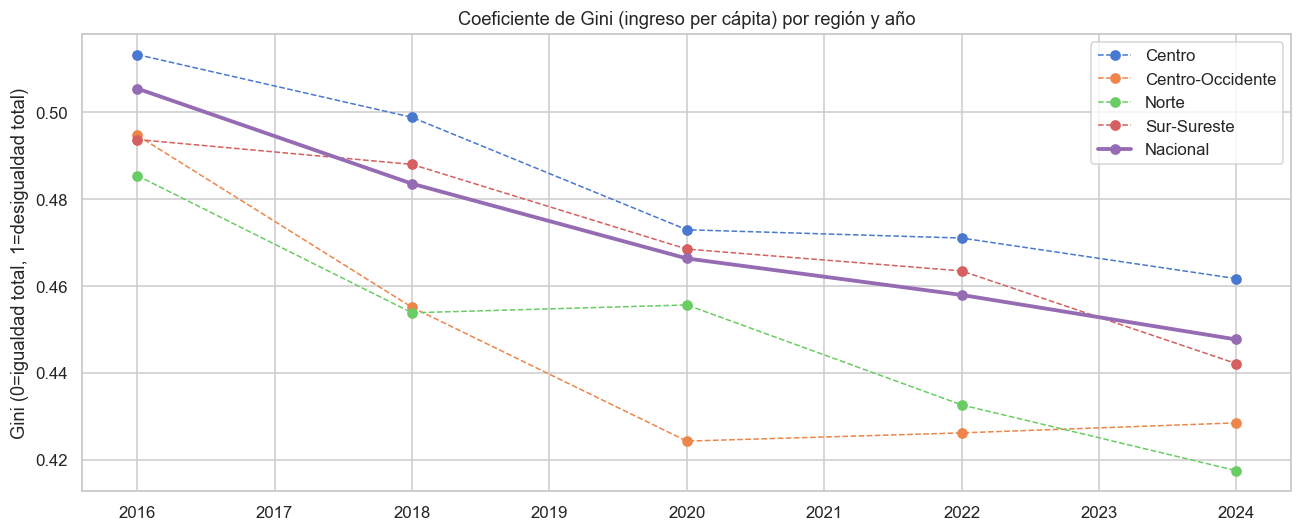

region  Centro  Centro-Occidente  Nacional  Norte  Sur-Sureste
anio                                                          
2016     0.513             0.495     0.506  0.485        0.494
2018     0.499             0.455     0.484  0.454        0.488
2020     0.473             0.424     0.466  0.456        0.469
2022     0.471             0.426     0.458  0.433        0.464
2024     0.462             0.429     0.448  0.418        0.442


In [62]:
def gini_weighted(values, weights):
    """Gini ponderado por factor de expansión."""
    mask = values.notna() & weights.notna() & (values >= 0)
    v, w = values[mask].values, weights[mask].values
    idx = np.argsort(v)
    v, w = v[idx], w[idx]
    cumw = np.cumsum(w)
    cumwv = np.cumsum(w * v)
    total_w = cumw[-1]
    total_wv = cumwv[-1]
    # Fórmula: G = 1 - (2/total_wv) * sum(cumwv_i * w_i / total_w) + (1/n) -- simplificada
    B = np.sum(cumwv[:-1] * w[1:]) / (total_w * total_wv)
    return 1 - 2 * B

gini_df = df.groupby(["anio","region"]).apply(
    lambda g: gini_weighted(g["ing_pc_mes"], g["factor"]),
    include_groups=False
).reset_index(name="gini")

gini_nac = df.groupby("anio").apply(
    lambda g: gini_weighted(g["ing_pc_mes"], g["factor"]),
    include_groups=False
).reset_index(name="gini")
gini_nac["region"] = "Nacional"

gini_all = pd.concat([gini_df, gini_nac], ignore_index=True)

fig, ax = plt.subplots()
for region in gini_all["region"].unique():
    sub = gini_all[gini_all["region"] == region]
    style = dict(linewidth=2.5, linestyle="-") if region == "Nacional" else dict(linewidth=1, linestyle="--")
    ax.plot(sub["anio"], sub["gini"], marker="o", label=region, **style)

ax.set_title("Coeficiente de Gini (ingreso per cápita) por región y año")
ax.set_ylabel("Gini (0=igualdad total, 1=desigualdad total)")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "mel_gini.png", dpi=150, bbox_inches="tight")
plt.show()

print(gini_all.pivot(index="anio", columns="region", values="gini").round(3).to_string())

## 9. Proxy de pobreza: tasa de hogares bajo línea de bienestar

> Las líneas usadas son **orientativas** (no deflactadas). Interpretarlas como tendencia, no como cifra oficial.

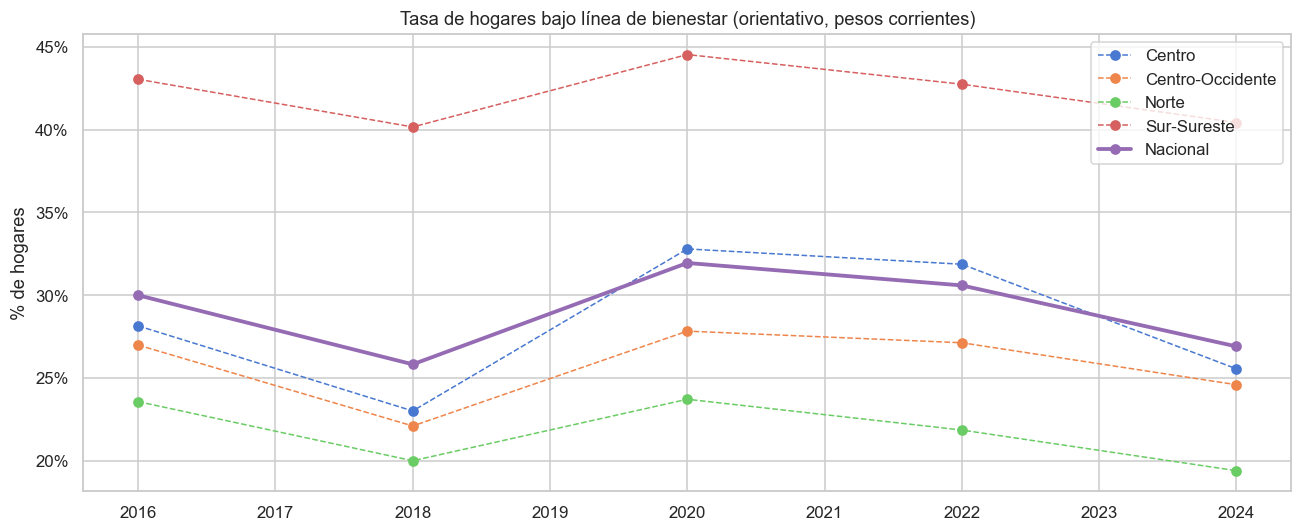


Tasa de pobreza (orientativa) por región y año:
region  Centro  Centro-Occidente  Nacional  Norte  Sur-Sureste
anio                                                          
2016      28.1              27.0      30.0   23.6         43.0
2018      23.0              22.1      25.8   20.0         40.2
2020      32.8              27.8      31.9   23.7         44.5
2022      31.9              27.1      30.6   21.8         42.8
2024      25.5              24.6      26.9   19.4         40.4


In [63]:
tasa_pob = df.dropna(subset=["pobre_lb"]).groupby(["anio","region"]).apply(
    lambda g: np.average(g["pobre_lb"], weights=g["factor"]),
    include_groups=False
).reset_index(name="tasa_pobreza")

tasa_nac = df.dropna(subset=["pobre_lb"]).groupby("anio").apply(
    lambda g: np.average(g["pobre_lb"], weights=g["factor"]),
    include_groups=False
).reset_index(name="tasa_pobreza")
tasa_nac["region"] = "Nacional"

tasa_all = pd.concat([tasa_pob, tasa_nac], ignore_index=True)

fig, ax = plt.subplots()
for region in tasa_all["region"].unique():
    sub = tasa_all[tasa_all["region"] == region]
    style = dict(linewidth=2.5, linestyle="-") if region == "Nacional" else dict(linewidth=1, linestyle="--")
    ax.plot(sub["anio"], sub["tasa_pobreza"] * 100, marker="o", label=region, **style)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title("Tasa de hogares bajo línea de bienestar (orientativo, pesos corrientes)")
ax.set_ylabel("% de hogares")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "mel_proxy_pobreza.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTasa de pobreza (orientativa) por región y año:")
print(
    tasa_all.pivot(index="anio", columns="region", values="tasa_pobreza")
    .mul(100).round(1).to_string()
)

## 10. Composición del ingreso: ¿de dónde viene la mejora?

Comparar qué fuentes de ingreso crecen: trabajo, transferencias gobierno (`bene_gob`), remesas.

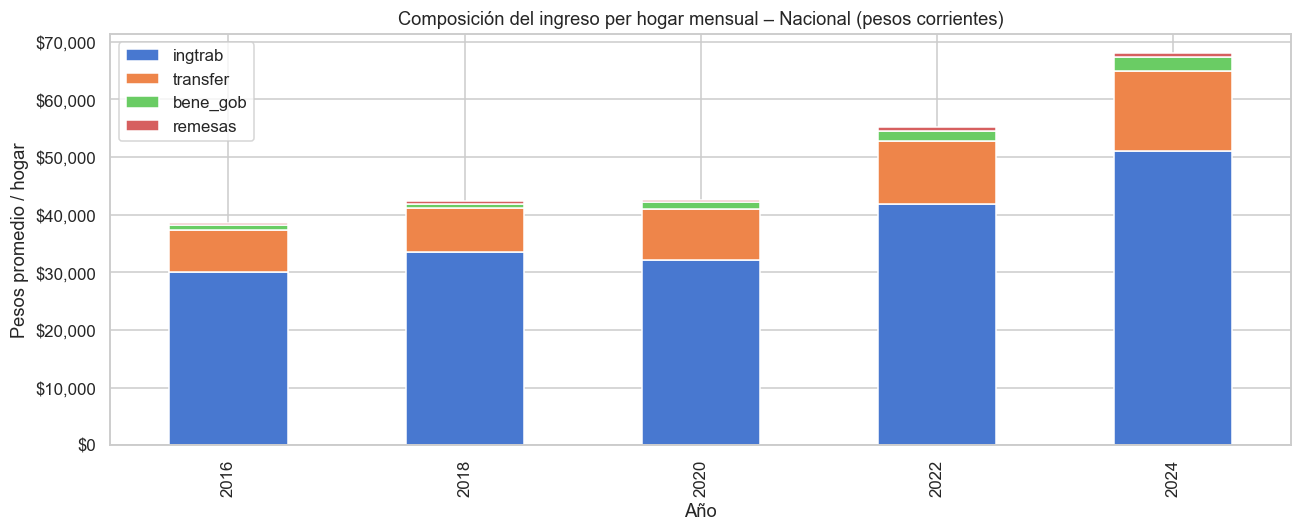

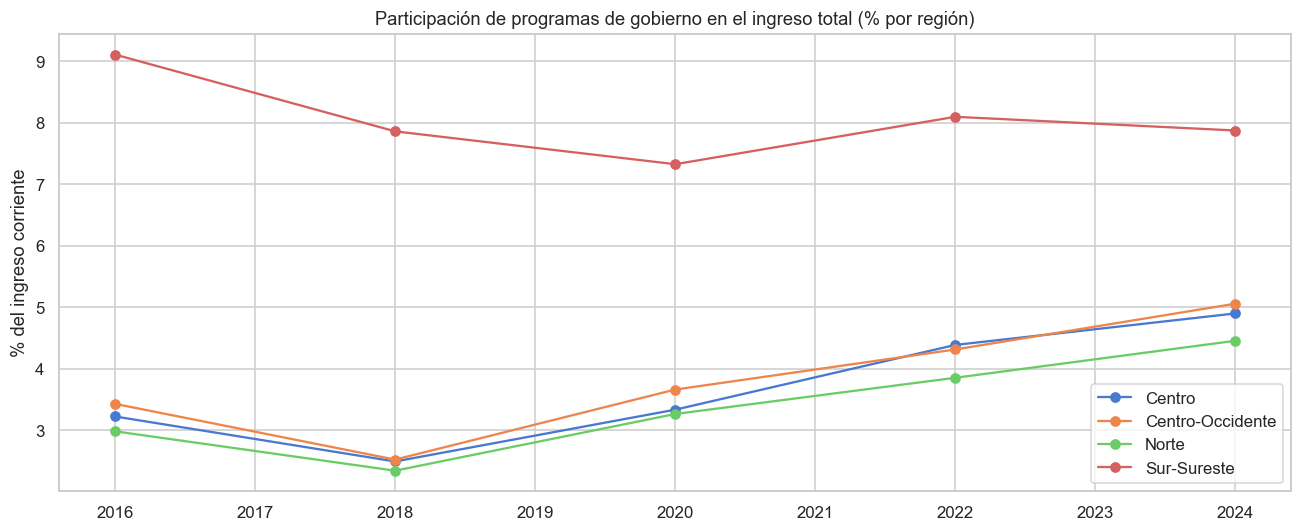

In [64]:
fuentes = ["ingtrab", "transfer", "bene_gob", "remesas"]

composicion_nac = df.groupby("anio").apply(
    lambda g: pd.Series({
        f: weighted_mean(g[f], g["factor"]) if f in g.columns else np.nan
        for f in fuentes
    }),
    include_groups=False
).reset_index()

composicion_reg = df.groupby(["anio","region"]).apply(
    lambda g: pd.Series({
        f: weighted_mean(g[f], g["factor"]) if f in g.columns else np.nan
        for f in fuentes
    }),
    include_groups=False
).reset_index()

# Gráfico nacional: composición apilada
comp_nac_pivot = composicion_nac.set_index("anio")[fuentes]
fig, ax = plt.subplots()
comp_nac_pivot.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Composición del ingreso per hogar mensual – Nacional (pesos corrientes)")
ax.set_ylabel("Pesos promedio / hogar")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Año")
plt.tight_layout()
plt.savefig(IMG_DIR / "mel_composicion_ingreso.png", dpi=150, bbox_inches="tight")
plt.savefig(IMG_DIR / "mel_share_bene_gob.png", dpi=150, bbox_inches="tight")
plt.show()

# % de bene_gob sobre ingreso total por región
df["share_benef"] = df["bene_gob"] / df["ing_cor"].clip(lower=1)

share_reg = df.groupby(["anio","region"]).apply(
    lambda g: weighted_mean(g["share_benef"], g["factor"]),
    include_groups=False
).reset_index(name="share_bene_gob")

fig, ax = plt.subplots()
for region in share_reg["region"].unique():
    sub = share_reg[share_reg["region"] == region]
    ax.plot(sub["anio"], sub["share_bene_gob"] * 100, marker="o", label=region)
ax.set_title("Participación de programas de gobierno en el ingreso total (% por región)")
ax.set_ylabel("% del ingreso corriente")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Heatmap: ingreso per cápita por estado y año (normalizado)

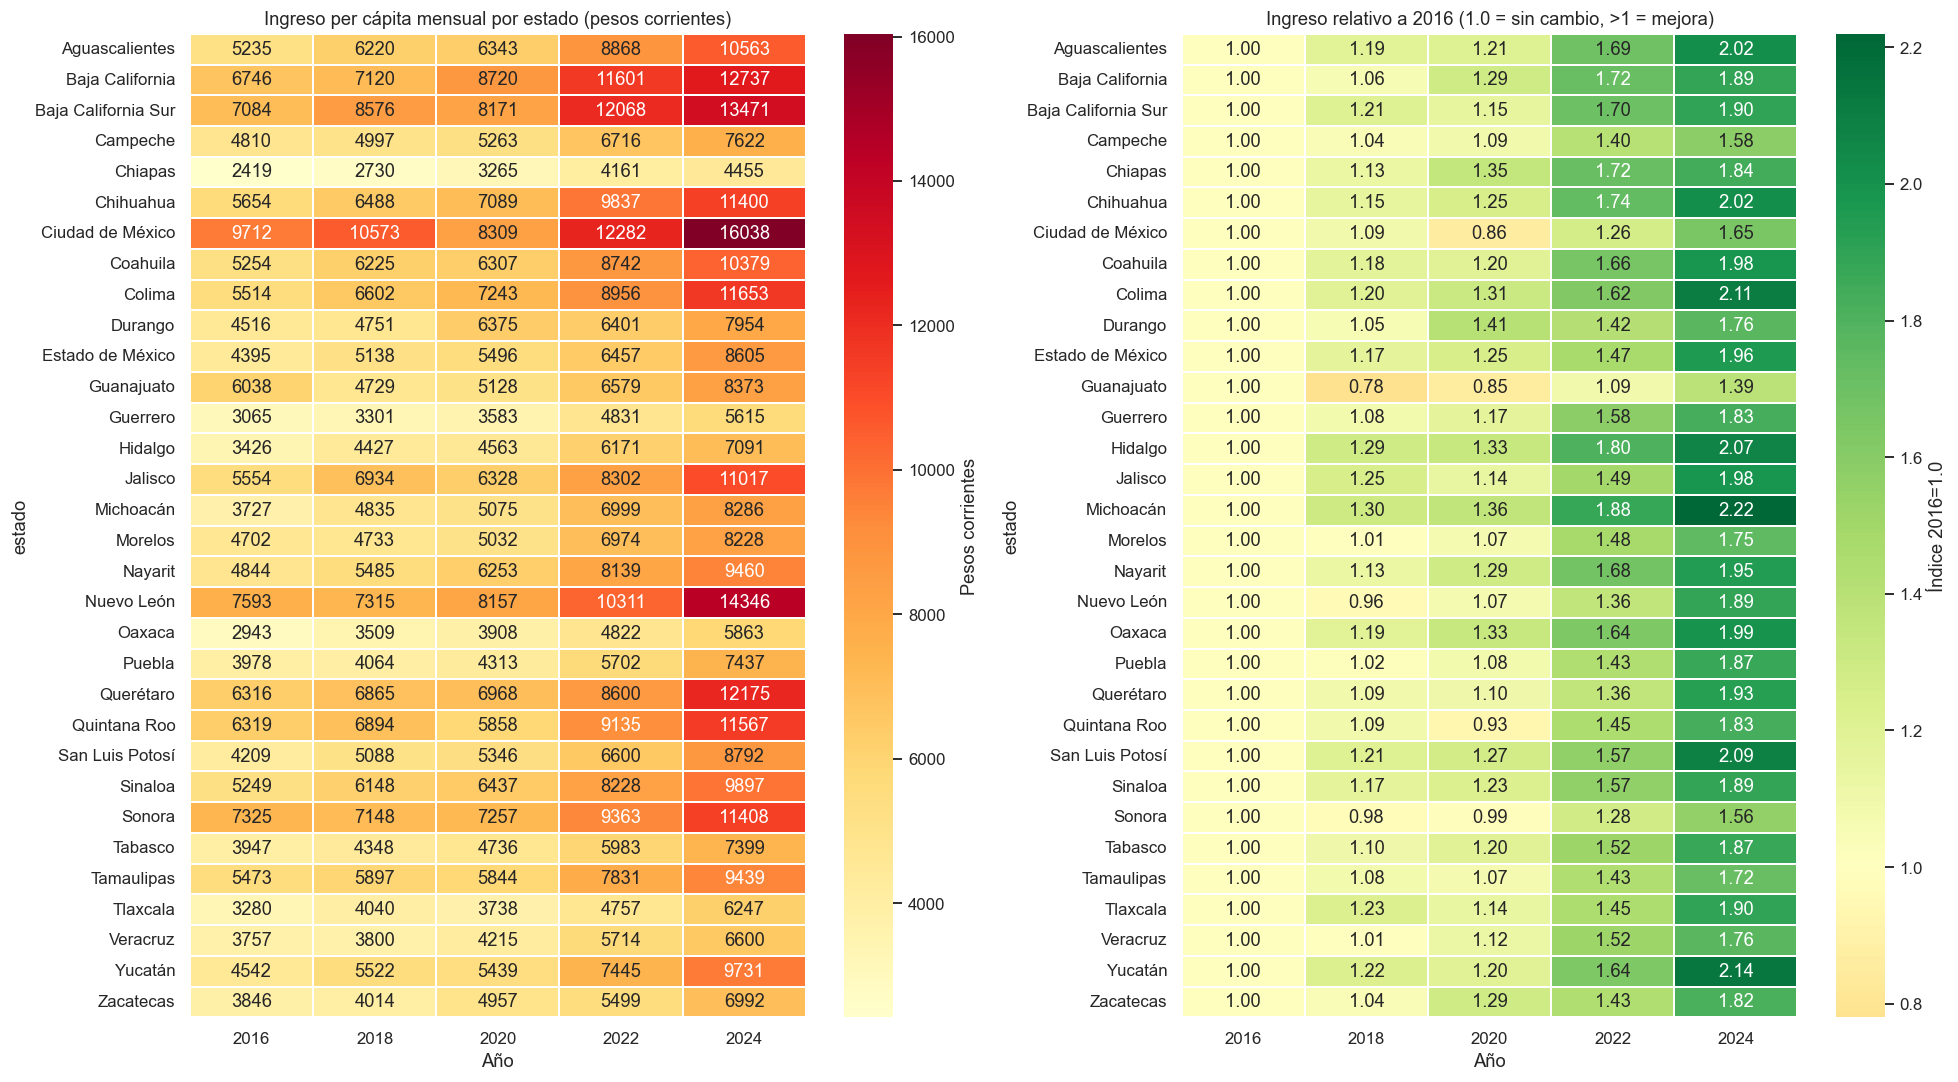

In [65]:
hm = por_estado.pivot(index="estado", columns="anio", values="ing_pc_media").dropna()

# Normalizar por fila: ver si cada estado mejoró vs su propio nivel de 2016
hm_norm = hm.div(hm[2016], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

sns.heatmap(hm.round(0), annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[0], linewidths=0.3, cbar_kws={"label": "Pesos corrientes"})
axes[0].set_title("Ingreso per cápita mensual por estado (pesos corrientes)")
axes[0].set_xlabel("Año")

sns.heatmap(hm_norm.round(2), annot=True, fmt=".2f", cmap="RdYlGn",
            ax=axes[1], linewidths=0.3, center=1.0,
            cbar_kws={"label": "Índice 2016=1.0"})
axes[1].set_title("Ingreso relativo a 2016 (1.0 = sin cambio, >1 = mejora)")
axes[1].set_xlabel("Año")

plt.tight_layout()
plt.savefig(IMG_DIR / "mel_heatmap_estados.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Resumen de hallazgos para la historia

Esta celda consolida las observaciones clave para orientar el relato.

In [66]:
print("=" * 65)
print("RESUMEN EXPLORATORIO: ¿México reduce pobreza equitativamente?")
print("=" * 65)

# 1. Cambio nacional en ingreso mediana
ing_2016 = nacional.set_index("anio").loc[2016, "ing_pc_mediana"]
ing_2024 = nacional.set_index("anio").loc[2024, "ing_pc_mediana"]
print(f"\n1. Ingreso mediana nacional 2016 → 2024:")
print(f"   ${ing_2016:,.0f} → ${ing_2024:,.0f} ({(ing_2024/ing_2016-1)*100:+.1f}% nominal)")
print("   ⚠️  Sin deflactar (incluye inflación ~90% en el período).")

# 2. Región con mayor y menor crecimiento
crec_reg = por_region[por_region["anio"].isin([2016,2024])].pivot(
    index="region", columns="anio", values="ing_pc_media"
).dropna()
crec_reg["cambio"] = (crec_reg[2024] / crec_reg[2016] - 1) * 100
print(f"\n2. Crecimiento nominal por macroregión 2016-2024:")
for reg, row in crec_reg["cambio"].sort_values(ascending=False).items():
    print(f"   {reg:<22} {row:+.1f}%")

# 3. Brecha Norte vs Sur
norte_24 = por_region[(por_region["anio"]==2024) & (por_region["region"]=="Norte")]["ing_pc_media"].values
sur_24   = por_region[(por_region["anio"]==2024) & (por_region["region"]=="Sur-Sureste")]["ing_pc_media"].values
if len(norte_24) and len(sur_24):
    print(f"\n3. Brecha Norte/Sur 2024: {norte_24[0]/sur_24[0]:.2f}x")
norte_16 = por_region[(por_region["anio"]==2016) & (por_region["region"]=="Norte")]["ing_pc_media"].values
sur_16   = por_region[(por_region["anio"]==2016) & (por_region["region"]=="Sur-Sureste")]["ing_pc_media"].values
if len(norte_16) and len(sur_16):
    print(f"   Brecha Norte/Sur 2016: {norte_16[0]/sur_16[0]:.2f}x")

# 4. Gini nacional
g16 = gini_all[(gini_all["region"]=="Nacional") & (gini_all["anio"]==2016)]["gini"].values
g24 = gini_all[(gini_all["region"]=="Nacional") & (gini_all["anio"]==2024)]["gini"].values
if len(g16) and len(g24):
    print(f"\n4. Gini nacional: 2016={g16[0]:.3f}  →  2024={g24[0]:.3f}")
    direction = "MEJORÓ (bajó)" if g24[0] < g16[0] else "EMPEORÓ (subió)"
    print(f"   Desigualdad {direction}")

print("\n" + "=" * 65)
print("VARIABLES MÁS ÚTILES PARA LA HISTORIA:")
print("  ing_cor, tot_integ  → proxy de pobreza por ingreso")
print("  ubica_geo           → desglose estatal / regional")
print("  factor              → expandir muestra a hogares reales")
print("  tam_loc             → brecha urbano-rural")
print("  bene_gob            → impacto de programas sociales")
print("  gasto_mon           → bienestar material complementario")
print("=" * 65)

RESUMEN EXPLORATORIO: ¿México reduce pobreza equitativamente?

1. Ingreso mediana nacional 2016 → 2024:
   $3,171 → $6,609 (+108.4% nominal)
   ⚠️  Sin deflactar (incluye inflación ~90% en el período).

2. Crecimiento nominal por macroregión 2016-2024:
   Norte                  +87.9%
   Sur-Sureste            +85.7%
   Centro-Occidente       +82.7%
   Centro                 +78.9%

3. Brecha Norte/Sur 2024: 1.64x
   Brecha Norte/Sur 2016: 1.63x

4. Gini nacional: 2016=0.506  →  2024=0.448
   Desigualdad MEJORÓ (bajó)

VARIABLES MÁS ÚTILES PARA LA HISTORIA:
  ing_cor, tot_integ  → proxy de pobreza por ingreso
  ubica_geo           → desglose estatal / regional
  factor              → expandir muestra a hogares reales
  tam_loc             → brecha urbano-rural
  bene_gob            → impacto de programas sociales
  gasto_mon           → bienestar material complementario
